# 부스팅 기초 + XGBoost 적용

앞 예측을 남기고 작은 보정을 순서대로 더하는 전략 학습

머신러닝 흐름: 문제 → 데이터 → 특성·정답 → 준비 → 학습·확인·최종 test → 학습 → 예측 → 평가 → 비교 → 설정 조정 → 다음 전략

앙상블 지도: Bagging / Random Forest / Voting / Boosting


### 준비 1/2 — 기본 도구와 사용할 열

아직 부스팅 모델은 불러오지 않음


In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
NUMERIC = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
CATEGORICAL = ["Sex", "Embarked"]

### 준비 2/2 — 같은 학습·비교용 데이터

최종 test는 사용하지 않음


In [26]:
def locate_data():
    matches = sorted(Path.cwd().rglob("titanic_train.csv"))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"titanic_train.csv를 하나만 찾을 수 있어야 합니다. 현재 {len(matches)}개입니다."
        )
    return matches[0]
data = pd.read_csv(locate_data()).sort_values("PassengerId").reset_index(drop=True)
positions = np.arange(len(data))
development_positions, final_positions = train_test_split(
    positions, test_size=0.20, stratify=data["Survived"], random_state=SEED
)
development = data.iloc[development_positions].copy().reset_index(drop=True)
FINAL_HOLDOUT_ROWS = len(final_positions)
del final_positions

X = development[FEATURES].copy()
y = development["Survived"].astype(int).copy()

## 1. 나란히 합치기와 순서대로 보정하기

- Bagging·RF·Voting: 여러 모델을 만든 뒤 결과 결합
- Boosting: 현재 예측의 부족한 방향을 다음 모델이 순서대로 보정

앞 모델을 버리지 않고 작은 보정을 더함


## 2. 회귀 Tree: 보정값을 만드는 다리

분류 Tree는 0/1을 예측함  
회귀 Tree는 마지막 잎에서 숫자를 낼 수 있음

예: 현재 예측에 `+0.15`를 더할 보정값 생성


In [27]:
from sklearn.tree import DecisionTreeRegressor

toy_x = np.array([[0], [1], [2], [3], [4], [5]])
toy_correction = np.array([-0.4, -0.3, -0.1, 0.2, 0.5, 0.6])
toy_tree = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(toy_x, toy_correction)
pd.DataFrame({"x": toy_x.ravel(), "필요한 보정": toy_correction, "Tree가 낸 숫자": toy_tree.predict(toy_x)})

,x,필요한 보정,Tree가 낸 숫자
0,0,-0.4,-0.266667
1,1,-0.3,-0.266667
2,2,-0.1,-0.266667
3,3,0.2,0.433333
4,4,0.5,0.433333
5,5,0.6,0.433333


## 3. 작은 학습기를 순서대로 더하기

작은 학습기(weak learner): 제한된 보정을 맡는 단순한 모델

아래 표에서 실제 정답 방향과 현재 점수 방향이 다른 사례 찾기


In [28]:
boosting_before = pd.DataFrame({
    "사례": list("ABCDE"),
    "실제": [1, 0, 1, 1, 0],
    "현재 점수": [0.45, 0.35, 0.20, -0.25, -0.40],
})
display(boosting_before)


,사례,실제,현재 점수
0,A,1,0.45
1,B,0,0.35
2,C,1,0.20
3,D,1,-0.25
4,E,0,-0.40


방향이 다른 사례에 필요한 보정 선택

- 양수 방향
- 음수 방향

앞 점수는 남겨 두고 새 보정값을 더함


In [29]:
boosting_after = boosting_before.assign(
    새_보정값=[0.00, -0.30, 0.00, 0.25, 0.00]
)
boosting_after["수정된 점수"] = (
    boosting_after["현재 점수"] + boosting_after["새_보정값"]
)
display(boosting_after)


,사례,실제,현재 점수,새_보정값,수정된 점수
0,A,1,0.45,0.00,0.45
1,B,0,0.35,-0.30,0.05
2,C,1,0.20,0.00,0.20
3,D,1,-0.25,0.25,0.00
4,E,0,-0.40,0.00,-0.40


### 앞 값을 남기고 더하기

현재 점수 `-0.10`, 새 보정값 `-0.25`

- 교체한 결과 계산
- 더한 결과 계산


In [30]:
current_score = -0.10
new_contribution = -0.25
print("교체한다면:", new_contribution)
print("더한다면:", current_score + new_contribution)

교체한다면: -0.25
더한다면: -0.35


## 4. AdaBoost: 틀린 사례의 중요도 변화

처음에는 다섯 사례의 중요도가 같음

1. 첫 번째 작은 Tree의 오분류 사례 표시
2. 다음 학습에서 중요도가 커질 사례 예상

중요도는 다음 모델 학습에 미치는 영향임


In [31]:
ada_activity = pd.DataFrame({
    "사례": list("ABCDE"),
    "실제": [1, 0, 1, 0, 1],
    "첫 Tree 예측": [1, 1, 1, 1, 1],
    "처음 중요도": [0.2] * 5,
})
ada_activity


,사례,실제,첫 Tree 예측,처음 중요도
0,A,1,1,0.2
1,B,0,1,0.2
2,C,1,1,0.2
3,D,0,1,0.2
4,E,1,1,0.2


오분류 사례를 표시한 뒤 다음 중요도 방향 선택

`커짐 / 작아짐 / 그대로`

공식 암기보다 첫 반복의 변화 방향 확인이 목표임


In [32]:
actual_signed = np.where(ada_activity["실제"].to_numpy() == 1, 1, -1)
pred_signed = np.where(ada_activity["첫 Tree 예측"].to_numpy() == 1, 1, -1)
initial_weight = ada_activity["처음 중요도"].to_numpy()
wrong = actual_signed != pred_signed
weighted_error = float(initial_weight[wrong].sum())
stump_strength = 0.5 * np.log((1 - weighted_error) / weighted_error)
next_weight = initial_weight * np.exp(-stump_strength * actual_signed * pred_signed)
next_weight = next_weight / next_weight.sum()
ada_weight_result = ada_activity.assign(
    오분류=np.where(wrong, "예", "아니오"),
    다음_중요도=next_weight,
)
ada_weight_result.style.format({"처음 중요도": "{:.3f}", "다음_중요도": "{:.3f}"})


,사례,실제,첫 Tree 예측,처음 중요도,오분류,다음_중요도
0,A,1,1,0.200,아니오,0.167
1,B,0,1,0.200,예,0.250
2,C,1,1,0.200,아니오,0.167
3,D,0,1,0.200,예,0.250
4,E,1,1,0.200,아니오,0.167


AdaBoost는 모든 사례를 남겨 둔 채 어려웠던 사례의 중요도를 높임

라벨 오류나 잡음까지 계속 강조하면 과적합할 수 있음


## 5. 손실(loss) → 방향 선택 → 기울기(gradient)

손실: 현재 예측이 얼마나 나쁜지 재는 값

실제 정답이 1이고 현재 1일 예측 확률이 0.55인 경우

1. 0.50과 0.80 중 손실이 줄어들 방향 선택
2. 표에서 실제 손실 변화 확인
3. 확인 뒤 기울기라는 이름 연결


In [33]:
probability_candidates = pd.DataFrame({
    "실제 정답": [1, 1, 1, 1],
    "1일 예측 확률": [0.50, 0.55, 0.65, 0.80],
})
probability_candidates["손실"] = -np.log(probability_candidates["1일 예측 확률"])
probability_candidates


,실제 정답,1일 예측 확률,손실
0,1,0.50,0.693147
1,1,0.55,0.597837
2,1,0.65,0.430783
3,1,0.80,0.223144


예측 확률이 0.55에서 0.80 쪽으로 움직이면 손실이 줄어듦

- 기울기(gradient): 손실이 가장 빨리 커지는 방향
- 손실을 줄이려면 그 반대 방향으로 이동
- 이 반대 방향을 음의 기울기(negative gradient)라 함
- 다음 작은 Tree가 그 방향의 보정값을 가까이 맞춤

손실 종류가 달라지면 보정 신호도 달라질 수 있음


## 6. 반영 비율과 반복 단계

- 학습률(learning rate): 새 보정값을 얼마나 반영할지 결정
- 반복 단계(round): 작은 학습기를 하나 더 추가하는 단계
- `n_estimators`: 반복 횟수

학습률이 작으면 더 많은 반복이 필요할 수 있음  
반복이 많다고 자동으로 좋아지는 것은 아님


In [34]:
current_score = 0.30
raw_correction = 0.40
rate_comparison = pd.DataFrame({"반영 비율": [1.0, 0.5, 0.1]})
rate_comparison["수정된 점수"] = (
    current_score + rate_comparison["반영 비율"] * raw_correction
)
rate_comparison


,반영 비율,수정된 점수
0,1.0,0.70
1,0.5,0.50
2,0.1,0.34


### 반복 횟수 읽기

`learning_rate=0.1`, `n_estimators=100`

각 보정의 10%를 반영하며 작은 Tree를 최대 100개까지 순서대로 더함


## 7. 과적합과 확인 데이터 그래프

과적합(overfitting): 학습 데이터에서는 계속 좋아지지만 확인 데이터에서는 나빠지는 상태

반복 단계가 늘어날 때 두 손실을 함께 확인

- 학습 손실
- 확인 손실


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def preprocessing(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), NUMERIC),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL),
    ])

def model_pipe(model, scale_numeric=False):
    return Pipeline([("prepare", preprocessing(scale_numeric)), ("model", model)])

In [36]:
X_t, X_v, y_t, y_v = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
gb_demo = model_pipe(GradientBoostingClassifier(
    n_estimators=180, learning_rate=0.12, max_depth=3, random_state=SEED
)).fit(X_t, y_t)
prep = gb_demo.named_steps["prepare"]
inner = gb_demo.named_steps["model"]
train_loss = [log_loss(y_t, p[:, 1]) for p in inner.staged_predict_proba(prep.transform(X_t))]
valid_loss = [log_loss(y_v, p[:, 1]) for p in inner.staged_predict_proba(prep.transform(X_v))]
best_round = int(np.argmin(valid_loss) + 1)
round_loss_table = pd.DataFrame({
    "반복": np.arange(1, len(train_loss) + 1),
    "학습 손실": train_loss,
    "확인 손실": valid_loss,
}).set_index("반복")


In [37]:
display(round_loss_table.loc[[1, 20]])

,학습 손실,확인 손실
반복,,
1,0.613159,0.610174
20,0.380324,0.399098


확인 손실이 가장 작은 반복: 42


<Axes: title={'center': '학습 손실과 확인 손실'}, xlabel='반복'>

/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/kwim/Dev/05_sparta/02_lectur

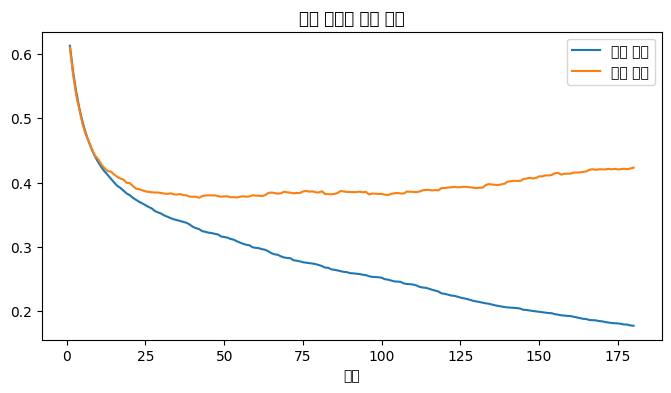

In [38]:
print("확인 손실이 가장 작은 반복:", best_round)
round_loss_table.plot(figsize=(8, 4), title="학습 손실과 확인 손실")


학습 손실만 보고 반복을 계속 늘리지 않음

확인 손실이 좋아지지 않을 때 멈추는 방법을 조기 종료(early stopping)라 함  
여기서는 개념만 확인하며 이미 정한 XGBoost 설정은 바꾸지 않음


## 8. Gradient Boosting과 XGBoost

XGBoost는 Gradient Boosting과 같은 순차 보정 계열임

- 복잡도 제어(regularization): 지나치게 복잡한 Tree에 불이익
- 곡선의 굽음 정보(Hessian): 손실 곡선의 주변 모양도 참고
- 계산·분기 탐색·결측 처리 개선

공식은 다루지 않음  
이 장치가 모든 데이터에서 더 좋은 결과를 보장하지는 않음


### 복잡도 제어와 곡선의 굽음 정보

- 복잡도 제어: 지나치게 복잡한 Tree 선택에 불이익
- 기울기: 현재 위치의 방향과 가파름 정보
- Hessian: 주변 손실 곡선의 굽음 정보

과적합 제거 또는 항상 더 높은 성능을 보장하지 않음


## 9. XGBoost 코드 읽기

이번 비교에 사용하는 설정

- `n_estimators=100`: 작은 Tree 100개
- `learning_rate=0.1`: 각 보정의 10% 반영
- `max_depth=3`: Tree 깊이 제한
- `random_state=42`: 난수 시작점 고정
- 두 비율 `1.0`: 행과 특성을 추가로 줄이지 않음

설정은 결과를 보기 전에 정함  
같은 학습·예측·평가 흐름 사용


In [39]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier

def make_xgb():
    return model_pipe(XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=1.0,
        colsample_bytree=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=1,
    ))

xgb = make_xgb()

In [40]:
xgb

Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model',
                 XGBClassifier(base_sc...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=1,
                               num_parallel_tree=None, ...))])

## 10. 같은 학습·비교용 데이터로 비교

Session 1 모델과 XGBoost를 같은 5겹 CV 기준으로 비교  
결과를 본 뒤 설정을 바꾸지 않음


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

lr = model_pipe(LogisticRegression(max_iter=2000, random_state=SEED), True)
knn = model_pipe(KNeighborsClassifier(n_neighbors=11), True)
tree = model_pipe(DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=SEED))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_row(name, candidate):
    scores = cross_val_score(candidate, X, y, cv=cv, scoring="accuracy", n_jobs=1)
    oof = cross_val_predict(candidate, X, y, cv=cv, method="predict", n_jobs=1)
    return {"모델/전략": name, "맞힌 수": int((oof == y).sum()),
            "CV 평균": scores.mean(), "CV 표준편차": scores.std()}

In [42]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, VotingClassifier

bagging = model_pipe(BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=SEED),
    n_estimators=200, random_state=SEED, n_jobs=1,
))
rf = model_pipe(RandomForestClassifier(
    n_estimators=200, max_depth=3, min_samples_leaf=5, max_features="sqrt",
    random_state=SEED, n_jobs=1,
))
hard_voting = VotingClassifier(
    estimators=[("lr", clone(lr)), ("knn", clone(knn)), ("tree", clone(tree))], voting="hard"
)
soft_voting = VotingClassifier(
    estimators=[("lr", clone(lr)), ("knn", clone(knn)), ("tree", clone(tree))], voting="soft"
)

### Hard Voting과 XGBoost 비교

실행 전 예상: 전체 정답 수가 늘어도 모든 승객의 예측이 같은 방향으로 좋아질까?


In [43]:
hard_oof = cross_val_predict(hard_voting, X, y, cv=cv, method="predict", n_jobs=1)
xgb_oof = cross_val_predict(xgb, X, y, cv=cv, method="predict", n_jobs=1)
hard_correct = hard_oof == y.to_numpy()
xgb_correct = xgb_oof == y.to_numpy()
changed = hard_oof != xgb_oof
xgb_only = changed & xgb_correct & ~hard_correct
hard_only = changed & hard_correct & ~xgb_correct
print("Hard Voting 정답 수:", int(hard_correct.sum()))
print("XGBoost 정답 수:", int(xgb_correct.sum()))
print("예측이 달라진 승객:", int(changed.sum()))
print("XGBoost만 정답:", int(xgb_only.sum()))
print("Hard Voting만 정답:", int(hard_only.sum()))
print("XGBoost 혼동행렬:")
print(confusion_matrix(y, xgb_oof))


Hard Voting 정답 수: 573
XGBoost 정답 수: 581
예측이 달라진 승객: 46
XGBoost만 정답: 27
Hard Voting만 정답: 19
XGBoost 혼동행렬:
[[390  49]
 [ 82 191]]


## XGBoost 결과와 혼동행렬 읽기

전체 정답 수와 오류 종류를 함께 확인  
한 점수 상승이 모든 승객의 개선이나 새 데이터 우월성을 뜻하지 않음


In [44]:
passenger_cards = development.loc[development["PassengerId"].isin([255, 19]), ["PassengerId"] + FEATURES + ["Survived"]].sort_values("PassengerId")
display(passenger_cards)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
9,19,3,female,31.0,1,0,18.0000,S,0
123,255,3,female,41.0,0,2,20.2125,S,0


In [45]:
for pid in [255, 19]:
    i = development.index[development["PassengerId"].eq(pid)][0]
    print({
        "PassengerId": pid,
        "실제 정답": int(y.iloc[i]),
        "Hard Voting": int(hard_oof[i]),
        "XGBoost": int(xgb_oof[i]),
    })


{'PassengerId': 255, '실제 정답': 0, 'Hard Voting': 1, 'XGBoost': 0}
{'PassengerId': 19, '실제 정답': 0, 'Hard Voting': 0, 'XGBoost': 1}


두 사례는 예측이 달라진 이유를 살펴보는 구체적인 확인임  
모델의 보편적인 우월성을 뜻하지 않음  
각 전략만 맞힌 사례를 모두 기록


`새로 맞힘 − 새로 틀림 = 순변화` 계산

평균 점수 하나가 모든 승객의 개선을 뜻하지 않음


In [46]:
changed_direction_table = pd.DataFrame({"방향": ["XGBoost만 정답", "Hard Voting만 정답"], "행 수": [int(xgb_only.sum()), int(hard_only.sum())]})
display(changed_direction_table)
print("순변화:", int(xgb_only.sum() - hard_only.sum()))

,방향,행 수
0,XGBoost만 정답,27
1,Hard Voting만 정답,19


순변화: 8


## 11. 비교 목적을 나눈 세 표

- A: 기본 모델 비교
- B: 같은 CV로 설정을 고른 결과
- C: 전략 비교

B는 설정 선택에 이미 사용한 결과임  
새 데이터 성능처럼 A·C와 합치지 않음


In [47]:
baseline_comparison = pd.DataFrame([
    cv_row("LR", lr), cv_row("KNN", knn), cv_row("Tree", tree),
])

selection_result = pd.DataFrame([{
    "표의 역할": "설정 선택에 사용한 결과",
    "후보 수": 9,
    "선택 설정": "max_depth=5, min_samples_leaf=5",
    "선택 CV 평균": 0.809002,
}])

strategy_comparison = pd.DataFrame([
    cv_row("Tree 기준", tree), cv_row("Bagging", bagging),
    cv_row("Random Forest", rf), cv_row("Hard Voting", hard_voting),
    cv_row("Soft Voting", soft_voting), cv_row("XGBoost", xgb),
])

print("A. 기본 모델 비교")
display(baseline_comparison.style.format({"CV 평균": "{:.3f}", "CV 표준편차": "{:.3f}"}))
print("B. 설정 선택 결과 — 새 데이터 성능을 뜻하지 않음")
display(selection_result.style.format({"선택 CV 평균": "{:.3f}"}))
print("C. 전략 비교")
display(strategy_comparison.style.format({"CV 평균": "{:.3f}", "CV 표준편차": "{:.3f}"}))


A. 기본 모델 비교


,모델/전략,맞힌 수,CV 평균,CV 표준편차
0,LR,567,0.796,0.028
1,KNN,572,0.803,0.008
2,Tree,573,0.805,0.011


B. 설정 선택 결과 — 새 데이터 성능을 뜻하지 않음


,표의 역할,후보 수,선택 설정,선택 CV 평균
0,설정 선택에 사용한 결과,9,"max_depth=5, min_samples_leaf=5",0.809


C. 전략 비교


,모델/전략,맞힌 수,CV 평균,CV 표준편차
0,Tree 기준,573,0.805,0.011
1,Bagging,573,0.805,0.014
2,Random Forest,573,0.805,0.029
3,Hard Voting,573,0.805,0.019
4,Soft Voting,574,0.806,0.026
5,XGBoost,581,0.816,0.035


| 모델/전략 | 판단·결합 방식 | 준비·설정 부담 |
|---|---|---|
| LR | 가중 합을 확률로 바꿈 | 스케일링 필요, 비교적 단순 |
| KNN | 가까운 이웃의 정답 확인 | 스케일링 중요, 이웃 수 선택 |
| Tree | 질문 경로 | 스케일링 불필요, 깊이 제어 |
| Bagging | 서로 다른 표본의 Tree 결합 | Tree 수·복잡도 설정 |
| RF | 표본과 분기 특성을 다르게 선택 | 정해 둔 설정 범위 |
| Hard/Soft Voting | 0/1 다수결 / 예측 확률 평균 | 구성 모델과 확률 품질 |
| XGBoost | 손실이 줄어드는 방향으로 순차 보정 | 학습률·반복·깊이를 함께 설정 |

한 번의 개발 결과로 어디서나 이기는 모델을 정하지 않음


## 12. 최종 모델 판단

세 문장으로 정리

1. 다음에 확인할 모델 선택
2. 지금 본 결과로 이유 작성
3. 다음 확인 항목 작성

최종 test를 열거나 결과를 본 뒤 설정을 다시 맞추는 행동은 제외


## 13. 새 이진분류 문제에 적용

고객 이탈 데이터의 모델링 순서 작성

1. 정답과 특성 확인
2. 빈칸·범주·스케일링 준비
3. 학습·확인·최종 test 역할 분리
4. LR·KNN·Tree를 같은 CV로 비교
5. 정해 둔 범위에서 설정 비교
6. 오류가 다르면 앙상블 고려
7. 선택 이유와 다음 확인 작성

마지막에 순서가 뒤집힌 곳이 없는지 스스로 확인


## 14. 마무리 확인

- 문제와 정답을 먼저 정했는가?
- 전처리를 모델의 판단 방식과 연결했는가?
- 모델 종류·설정·전략 비교를 구분했는가?
- 최종 test를 선택에 사용하지 않았는가?

**문제가 도구보다 먼저임. 예측 결과를 해석해 다음 질문과 설계로 연결함.**
